In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('../data/gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.shape

(3554, 18)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [6]:
latlong = pd.read_csv("../data/latlong.csv")

In [7]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [8]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [9]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [10]:
new_df = df.merge(latlong, on='sector')

In [11]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [12]:
group_df = new_df.groupby('sector').mean(numeric_only=True)[['price','price_per_sqft','built_up_area','latitude','longitude']]

In [13]:
group_df


,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 10,2.092857,11866.571429,1908.857143,28.4537,77.0009
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
...,...,...,...,...,...
sector 91,1.648235,7586.117647,2028.647059,28.4014,76.9225
sector 92,0.934000,5928.290000,1571.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326


In [14]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

C:\Users\ajjur\AppData\Local\Temp\ipykernel_5164\860414701.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',


In [15]:
new_df.to_csv('../data/data_viz1.csv',index=False)

In [16]:
df1 = pd.read_csv('../data/gurgaon_properties.csv')

In [17]:
df1.head()


,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Sector 90 Gurgaon,flat,shree vardhman flora,0.85,4404.0,1930.0,Super Built up area 1930(179.3 sq.m.)Carpet ar...,3,4,3,"servant room,store room","305, Sector 90 Gurgaon, Gurgaon, Haryana",3.0,South-East,1 to 5 Year Old,"['IRIS Broadway Mall', 'Dwarka Expressway', 'S...",One of the best location of the society with g...,NaN,"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area5 out of 5', 'Construction5 out of..."
1,2 BHK Flat in Sohna,flat,gls arawali homes,0.27,4600.0,587.0,Super Built up area 576(53.51 sq.m.),2,2,2,not available,"Sohna, Gurgaon, Haryana",5.0,NaN,0 to 1 Year Old,"['Huda City Centre', 'Golf Course Road', 'Delh...",Tower 13 floor 5th house no. 508. Freehold pro...,[],"['Feng Shui / Vaastu Compliant', 'Intercom Fac...","['Management4 out of 5', 'Green Area5 out of 5..."
2,2 Bedroom House for sale in Sector 70A Gurgaon,house,bptp pedestal,0.90,7582.0,1187.0,Carpet area: 1187 (110.28 sq.m.),2,2,3+,"servant room,others","123, Sector 70A Gurgaon, Gurgaon, Haryana",3.0,North-East,0 to 1 Year Old,"['Ninex Mall', 'Airia Mall', 'Meditree Market'...",This 2 bhk house for sale in sector 70a gurgao...,"['1 Exhaust Fan', '3 AC', '1 Modular Kitchen',...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Environment5 out of 5', 'Safety4 out of 5', ..."
3,4 BHK Flat in Sector-33 Sohna,flat,central park flower valley,2.30,12777.0,1800.0,Carpet area: 1800 (167.23 sq.m.),4,4,3+,"pooja room,servant room","Sector-33 Sohna, Gurgaon, Haryana",5.0,North-East,0 to 1 Year Old,"['Golf Course Extension Rd', 'Rajiv Chowk - So...",9 sports academiesMulti-Cuisine restaurantKids...,"['4 Wardrobe', '4 Fan', '18 Light', '1 Chimney...","['Feng Shui / Vaastu Compliant', 'Security / F...",NaN
4,3 BHK Flat in Sector 92 Gurgaon,flat,sare crescent parc,0.51,4080.0,1250.0,Super Built up area 1250(116.13 sq.m.),3,2,2,not available,"Sare, Sector 92 Gurgaon, Gurgaon, Haryana",2.0,North,1 to 5 Year Old,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",Ready to move in keys in hand for visit feel f...,[],"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Green Area4 out of 5', 'Construction4 out of..."


In [18]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [19]:
wordcloud_df.head()

,features,sector
0,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 36
1,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",sector 89
2,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sohna road
3,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 92
4,"['Power Back-up', 'Intercom Facility', 'Lift(s...",sector 102


In [20]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [21]:
main

['Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'No open drainage around',
 'Bank Attached Property',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Natural Light',
 'Airy Rooms',
 'Low Density Society',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Water softening plant',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'Park',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Rain Water Harvesting',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Centrally Air Conditioned',
 'Water purifier',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'Recently Renovated',
 'Piped-gas',
 'Visitor Parking',
 'Swimming Poo

In [23]:
!pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable
  Using cached wordcloud-1.9.4-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.4-cp313-cp313-win_amd64.whl (300 kB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.17.0 requires dacite>=1.8, which is not installed.
ydata-profiling 4.17.0 requires filetype>=1.0.0, which is not installed.
ydata-profiling 4.17.0 requires imagehash==4.3.1, which is not installed.
ydata-profiling 4.17.0 requires minify-html>=0.15.0, which is not installed.
ydata-profiling 4.17.0 requires multimethod<2,>=1.4, which is not installed.
ydata-profiling 4.17.0 requires typeguard<5,>=3, which is not installed.
ydata-profiling 4.17.0 requires visions[type_image_path]<0.8.2,>=0.7.5, which is not installed.
ydata-profiling 4.17.0 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.6 which is incompatible.
ydata-profiling 4.17.0 requires numba<=0.61,>=0.56.0, but you have numba 0.62.0 which is incompatible.
ydata-profiling 4.17.0 requires phik<0.13,>=0.11.1, but you have phik 0.1

In [24]:
from wordcloud import WordCloud

In [25]:
feature_text = ' '.join(main)

In [26]:
import pickle
pickle.dump(feature_text, open('../models/feature_text.pkl','wb'))

In [27]:
feature_text

'Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff Water Storage No open drainage around Bank Attached Property Visitor Parking Swimming Pool Park Natural Light Airy Rooms Low Density Society Shopping Centre Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Water softening plant Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Park Shopping Centre Fitness Centre / GYM Club house / Community Center Rain Water Harvesting Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Centrally Air Conditioned Water purifier High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room Recently Renovated Piped-gas Visitor Parking Swimming Pool Park Security Personnel Natural Light Internet/wi-fi connectivity Airy Rooms Spacious Interiors Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Comm

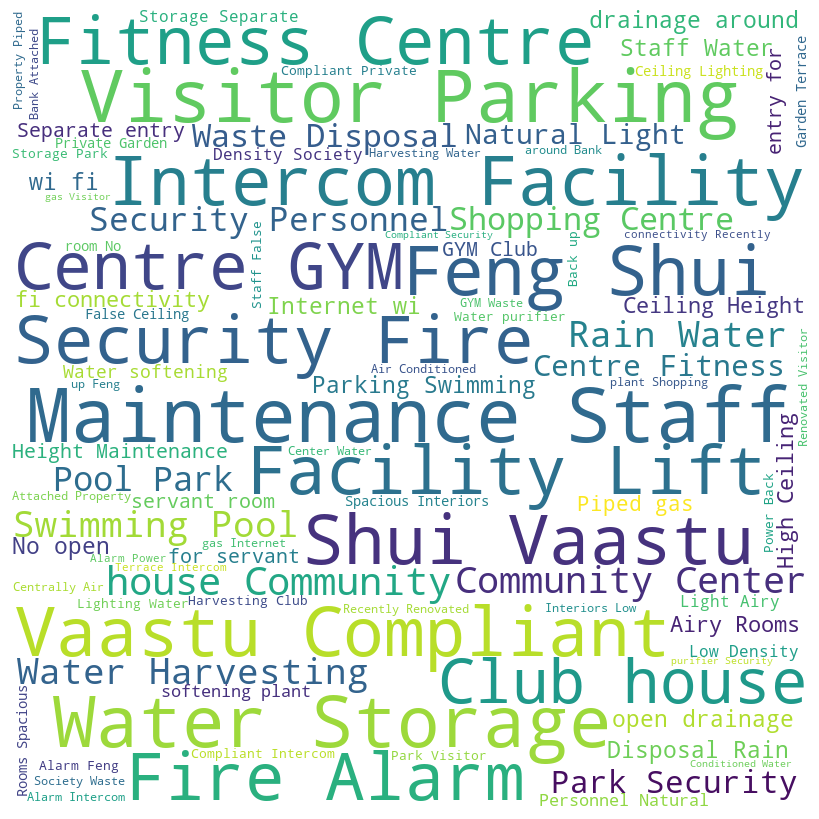

In [28]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [29]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [30]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [31]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [32]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

C:\Users\ajjur\AppData\Local\Temp\ipykernel_5164\3761596323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\ajjur\AppData\Local\Temp\ipykernel_5164\3761596323.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

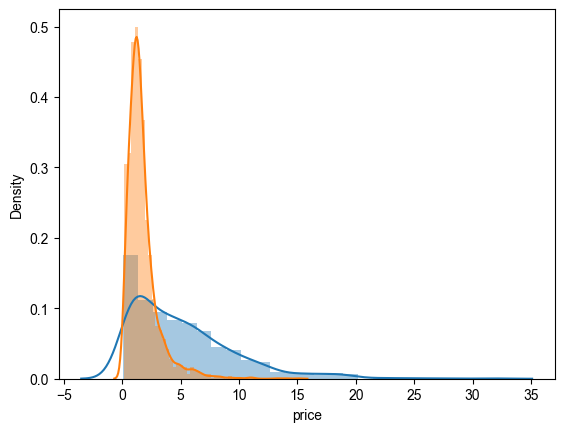

In [33]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [34]:
new_df['sector'].unique().tolist().insert(0,'overall')